# Three-model agreement/disagreement analysis

This notebook reproduces the analysis and figures from the original three-model pipeline without loading or calling Qwen, Llama, or Mistral.

## Required input

One full candidate-level CSV, read directly from the original pipeline output:

`matched_ukb_full_final_since_2014_three_model_combined_labels.csv`

It must contain `id`, `title`, `abstract`, `year`, and the saved label/parse columns for all three models. The TRUE-agreement-only export is not sufficient because most analyses compare TRUE agreement with the remaining candidates.

## Outputs

Every derived table is saved as CSV and every figure as PNG and PDF. Figures are also displayed inline so they remain visible when the executed notebook is shared.

## 1. Install analysis dependencies

No tagging models or API credentials are required.

In [1]:
%pip -q install --upgrade-strategy only-if-needed pandas numpy matplotlib seaborn scikit-learn sentence-transformers

## 2. Set paths



In [2]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

INPUT_PATH = Path('YOUR PATH')
OUTPUT_DIR = INPUT_PATH.parent / "analysis_only_rerun"
FIGURE_DIR = OUTPUT_DIR / "figures"

RUN_SEMANTIC_ANALYSIS = True
MAX_TFIDF_PER_GROUP = 20_000
MAX_SEMANTIC_PER_GROUP = 3_000
SEED = 42

LCDS_PALETTE = ["#344874", "#FFBB00", "#5B8DB8", "#2A9D8F", "#E76F51", "#8E6C9E"]

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Combined consensus CSV not found in Drive: {INPUT_PATH}\n"
        "Check that the original three-model pipeline completed its consensus-save stage."
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input: {INPUT_PATH}")
print(f"Input size: {INPUT_PATH.stat().st_size / 1024**2:.1f} MB")
print(f"Outputs: {OUTPUT_DIR}")


Mounted at /content/drive
Input: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/matched_ukb_full_final_since_2014_three_model_combined_labels.csv
Input size: 350.5 MB
Outputs: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun


## 3. Imports and reusable helpers

In [3]:
import gc
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

MODEL_NAMES = ["qwen", "llama3_8b", "mistral_7b"]
MODEL_DISPLAY = {"qwen": "Qwen2.5-7B", "llama3_8b": "Llama3-8B", "mistral_7b": "Mistral-7B"}


def normalise_label(series):
    result = pd.Series(pd.NA, index=series.index, dtype="Int64")
    numeric = pd.to_numeric(series, errors="coerce")
    result.loc[numeric.eq(1)] = 1
    result.loc[numeric.eq(0)] = 0
    text = series.astype(str).str.strip().str.lower()
    result.loc[text.isin(["true", "yes", "y", "1", "1.0"])] = 1
    result.loc[text.isin(["false", "no", "n", "0", "0.0"])] = 0
    return result


def normalise_bool(series):
    if series.dtype == bool:
        return series.fillna(False).astype(bool)
    text = series.astype(str).str.strip().str.lower()
    return text.map({
        "true": True, "1": True, "1.0": True, "yes": True, "y": True,
        "false": False, "0": False, "0.0": False, "no": False, "n": False,
        "nan": False, "none": False, "<na>": False, "": False,
    }).fillna(False).astype(bool)


def clean_year(series):
    years = pd.to_numeric(series, errors="coerce")
    return years.where(years.between(1900, 2035)).astype("Int64")


def analysis_text(frame):
    return (
        frame["title"].fillna("").astype(str).str.strip()
        + "\n"
        + frame["abstract"].fillna("").astype(str).str.strip()
    )


def save_table(frame, filename):
    path = OUTPUT_DIR / filename
    frame.to_csv(path, index=False)
    print(f"Saved table: {path}")
    return path


def save_figure(figure, filename):
    figure.tight_layout()
    png_path = FIGURE_DIR / f"{filename}.png"
    pdf_path = FIGURE_DIR / f"{filename}.pdf"
    figure.savefig(png_path, dpi=300, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    display(figure)
    plt.close(figure)
    print(f"Saved figure: {png_path}")
    return png_path

## 4. Load, validate, and rebuild consensus fields

**Outputs:**

- `combined_consensus_normalised.csv`
- `three_model_TRUE_agreement.csv`
- `rest_NOT_three_model_TRUE_agreement.csv`

In [4]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Combined consensus CSV not found: {INPUT_PATH}\n"
        "Update INPUT_PATH in Section 2. Do not use the TRUE-agreement-only export."
    )

combined = pd.read_csv(INPUT_PATH, low_memory=False)
required = {"id", "title", "abstract", "year"}
for model in MODEL_NAMES:
    required.update({f"{model}_label", f"{model}_parse_ok"})

missing = sorted(required - set(combined.columns))
if missing:
    raise ValueError(f"The combined consensus CSV is missing required columns: {missing}")

combined["id"] = combined["id"].astype(str).str.strip()
combined = combined[combined["id"].ne("")].drop_duplicates("id", keep="first").reset_index(drop=True)
combined["title"] = combined["title"].fillna("").astype(str)
combined["abstract"] = combined["abstract"].fillna("").astype(str)
combined["year_int"] = clean_year(combined["year"])

for model in MODEL_NAMES:
    combined[f"{model}_label"] = normalise_label(combined[f"{model}_label"])
    combined[f"{model}_parse_ok"] = normalise_bool(combined[f"{model}_parse_ok"])
    combined[f"{model}_true"] = combined[f"{model}_parse_ok"] & combined[f"{model}_label"].eq(1)
    combined[f"{model}_false"] = combined[f"{model}_parse_ok"] & combined[f"{model}_label"].eq(0)

combined["n_models_parsed"] = sum(combined[f"{model}_parse_ok"].astype(int) for model in MODEL_NAMES)
combined["n_true_votes"] = sum(combined[f"{model}_true"].astype(int) for model in MODEL_NAMES)
combined["n_false_votes"] = sum(combined[f"{model}_false"].astype(int) for model in MODEL_NAMES)
combined["all_three_parsed"] = combined["n_models_parsed"].eq(3)
combined["three_model_TRUE_agreement"] = np.logical_and.reduce(
    [combined[f"{model}_true"] for model in MODEL_NAMES]
)
combined["three_model_FALSE_agreement"] = np.logical_and.reduce(
    [combined[f"{model}_false"] for model in MODEL_NAMES]
)


def vote_signature(row):
    values = []
    for model in MODEL_NAMES:
        if not row[f"{model}_parse_ok"]:
            value = "NA"
        else:
            value = "T" if row[f"{model}_label"] == 1 else "F"
        values.append(f"{model}={value}")
    return " | ".join(values)


def consensus_group(row):
    if row["three_model_TRUE_agreement"]:
        return "Three-model TRUE agreement"
    if row["three_model_FALSE_agreement"]:
        return "Three-model FALSE agreement"
    if row["n_true_votes"] == 2:
        return "Two TRUE votes"
    if row["n_true_votes"] == 1:
        return "One TRUE vote"
    if row["n_models_parsed"] > 0:
        return "No TRUE votes / parsed non-positive"
    return "No parsed model labels"


combined["vote_signature"] = combined.apply(vote_signature, axis=1)
combined["consensus_group"] = combined.apply(consensus_group, axis=1)

three_true = combined[combined["three_model_TRUE_agreement"]].copy()
rest = combined[~combined["three_model_TRUE_agreement"]].copy()

if three_true.empty or rest.empty:
    raise ValueError(
        "Both consensus groups are required. This appears to be a subset export. "
        "Use matched_ukb_full_final_since_2014_three_model_combined_labels.csv."
    )

save_table(combined, "combined_consensus_normalised.csv")
save_table(three_true, "three_model_TRUE_agreement.csv")
save_table(rest, "rest_NOT_three_model_TRUE_agreement.csv")

print(f"Candidates: {len(combined):,}")
print(f"Three-model TRUE agreement: {len(three_true):,}")
print(f"Rest: {len(rest):,}")
display(combined[["id", "year_int", "n_true_votes", "consensus_group"]].head())

Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/combined_consensus_normalised.csv
Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/three_model_TRUE_agreement.csv
Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/rest_NOT_three_model_TRUE_agreement.csv
Candidates: 178,343
Three-model TRUE agreement: 24,295
Rest: 154,048


,id,year_int,n_true_votes,consensus_group
0,pub.1150118486,2022,0,Three-model FALSE agreement
1,pub.1186145872,2025,1,One TRUE vote
2,pub.1046949937,2016,0,Three-model FALSE agreement
3,pub.1173505922,2024,0,Three-model FALSE agreement
4,pub.1158345696,2023,0,Three-model FALSE agreement


## 5. Dataset overview

**Output:** `dataset_overview.csv`

In [5]:
overview = pd.DataFrame([
    {"metric": "total_candidates", "value": len(combined)},
    {"metric": "unique_ids", "value": combined["id"].nunique()},
    {"metric": "three_model_TRUE_agreement", "value": len(three_true)},
    {"metric": "rest_NOT_three_model_TRUE_agreement", "value": len(rest)},
    {"metric": "three_model_TRUE_agreement_percent", "value": 100 * len(three_true) / len(combined)},
    {"metric": "three_model_FALSE_agreement", "value": int(combined["three_model_FALSE_agreement"].sum())},
    {"metric": "all_three_parsed", "value": int(combined["all_three_parsed"].sum())},
    {"metric": "earliest_year", "value": combined["year_int"].min()},
    {"metric": "latest_year", "value": combined["year_int"].max()},
])
save_table(overview, "dataset_overview.csv")
display(overview)

Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/dataset_overview.csv


,metric,value
0,total_candidates,178343.000000
1,unique_ids,178343.000000
2,three_model_TRUE_agreement,24295.000000
3,rest_NOT_three_model_TRUE_agreement,154048.000000
4,three_model_TRUE_agreement_percent,13.622626
5,three_model_FALSE_agreement,136651.000000
6,all_three_parsed,178314.000000
7,earliest_year,2014.000000
8,latest_year,2026.000000


## 6. Consensus statistics and distributions

**Outputs:**

- `model_positive_rate_summary.csv`
- `true_vote_distribution.csv`
- `consensus_group_distribution.csv`
- `vote_signature_distribution.csv`

In [6]:
model_summary = []
for model in MODEL_NAMES:
    parsed = int(combined[f"{model}_parse_ok"].sum())
    true = int(combined[f"{model}_true"].sum())
    false = int(combined[f"{model}_false"].sum())
    model_summary.append({
        "model": model,
        "display_name": MODEL_DISPLAY[model],
        "parsed": parsed,
        "true": true,
        "false": false,
        "parse_rate_percent": 100 * parsed / len(combined),
        "true_percent_among_parsed": 100 * true / max(parsed, 1),
    })

model_summary = pd.DataFrame(model_summary)
vote_distribution = combined["n_true_votes"].value_counts().sort_index().rename_axis("n_true_votes").reset_index(name="n_candidates")
group_distribution = combined["consensus_group"].value_counts().rename_axis("consensus_group").reset_index(name="n_candidates")
signature_distribution = combined["vote_signature"].value_counts().rename_axis("vote_signature").reset_index(name="n_candidates")

save_table(model_summary, "model_positive_rate_summary.csv")
save_table(vote_distribution, "true_vote_distribution.csv")
save_table(group_distribution, "consensus_group_distribution.csv")
save_table(signature_distribution, "vote_signature_distribution.csv")

display(model_summary)
display(vote_distribution)
display(group_distribution)
display(signature_distribution)

Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/model_positive_rate_summary.csv
Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/true_vote_distribution.csv
Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/consensus_group_distribution.csv
Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/vote_signature_distribution.csv


,model,display_name,parsed,true,false,parse_rate_percent,true_percent_among_parsed
0,qwen,Qwen2.5-7B,178315,25702,152613,99.984300,14.413818
1,llama3_8b,Llama3-8B,178342,40818,137524,99.999439,22.887486
2,mistral_7b,Mistral-7B,178343,26642,151701,100.000000,14.938629


,n_true_votes,n_candidates
0,0,136680
1,1,14459
2,2,2909
3,3,24295


,consensus_group,n_candidates
0,Three-model FALSE agreement,136651
1,Three-model TRUE agreement,24295
2,One TRUE vote,14459
3,Two TRUE votes,2909
4,No TRUE votes / parsed non-positive,29


,vote_signature,n_candidates
0,qwen=F | llama3_8b=F | mistral_7b=F,136651
1,qwen=T | llama3_8b=T | mistral_7b=T,24295
2,qwen=F | llama3_8b=T | mistral_7b=F,13657
3,qwen=F | llama3_8b=T | mistral_7b=T,1728
4,qwen=T | llama3_8b=T | mistral_7b=F,1138
5,qwen=F | llama3_8b=F | mistral_7b=T,576
6,qwen=T | llama3_8b=F | mistral_7b=F,226
7,qwen=T | llama3_8b=F | mistral_7b=T,43
8,qwen=NA | llama3_8b=F | mistral_7b=F,28
9,qwen=F | llama3_8b=NA | mistral_7b=F,1


## 7. Model positive rates

**Figure:** `model_positive_rate_summary`

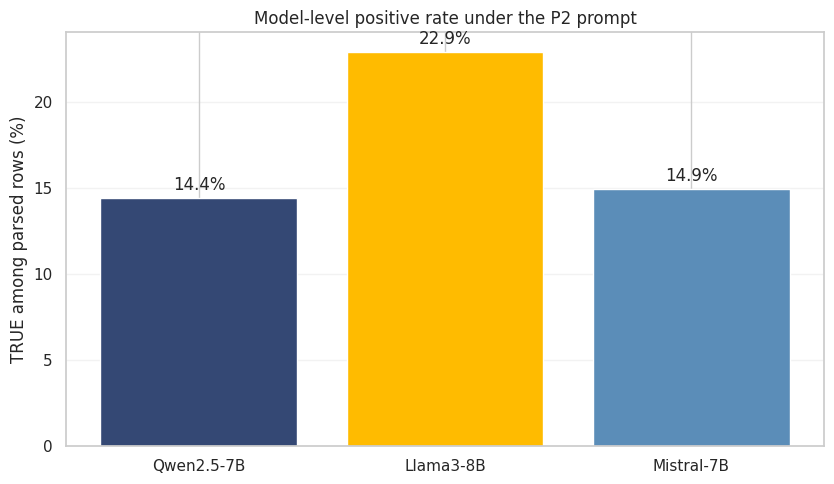

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/model_positive_rate_summary.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/model_positive_rate_summary.png')

In [7]:
figure, axis = plt.subplots(figsize=(8.5, 5))
bars = axis.bar(model_summary["display_name"], model_summary["true_percent_among_parsed"], color=LCDS_PALETTE[:3])
axis.set(title="Model-level positive rate under the P2 prompt", ylabel="TRUE among parsed rows (%)")
axis.grid(axis="y", alpha=0.25)
axis.bar_label(bars, fmt="%.1f%%", padding=3)
save_figure(figure, "model_positive_rate_summary")

## 8. TRUE-vote distribution

**Figure:** `true_vote_distribution`

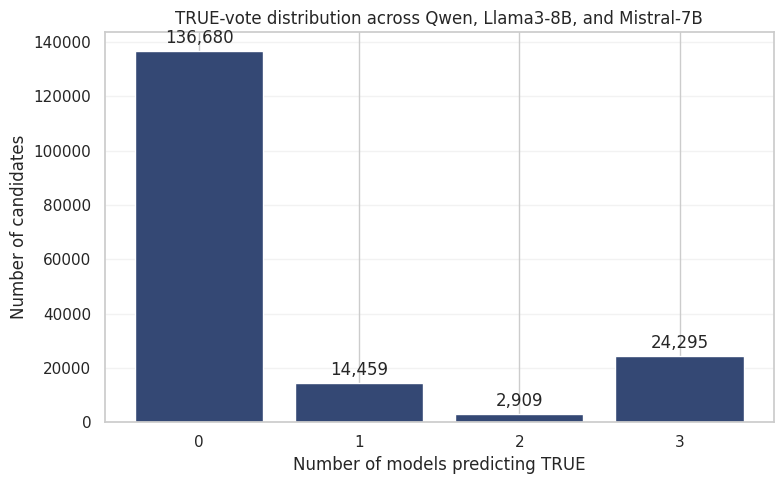

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/true_vote_distribution.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/true_vote_distribution.png')

In [8]:
figure, axis = plt.subplots(figsize=(8, 5))
bars = axis.bar(vote_distribution["n_true_votes"].astype(str), vote_distribution["n_candidates"], color=LCDS_PALETTE[0])
axis.set(
    title="TRUE-vote distribution across Qwen, Llama3-8B, and Mistral-7B",
    xlabel="Number of models predicting TRUE",
    ylabel="Number of candidates",
)
axis.grid(axis="y", alpha=0.25)
axis.bar_label(bars, labels=[f"{value:,}" for value in vote_distribution["n_candidates"]], padding=3)
save_figure(figure, "true_vote_distribution")

## 9. Consensus-group distribution

**Figure:** `consensus_group_distribution`

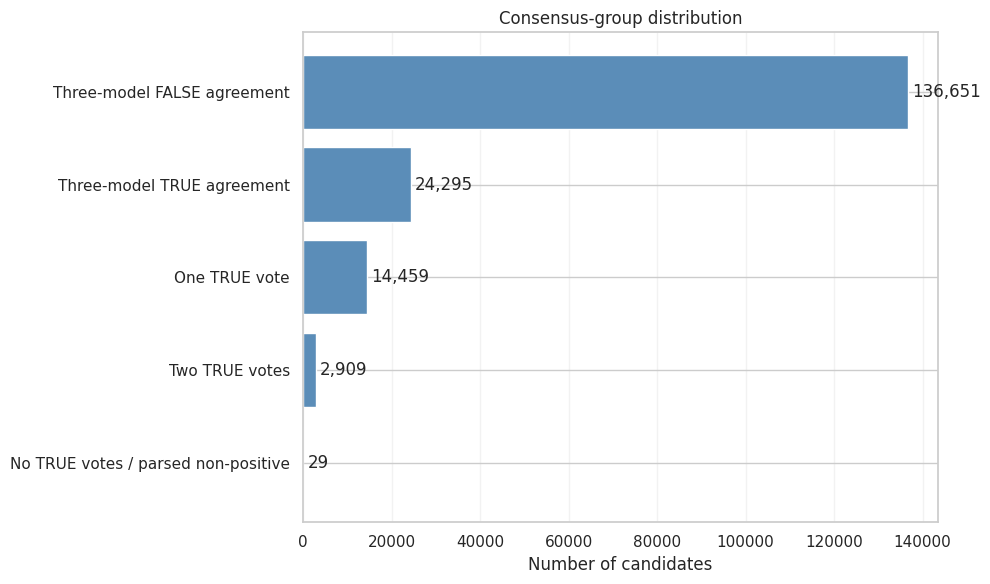

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/consensus_group_distribution.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/consensus_group_distribution.png')

In [9]:
plot_data = group_distribution.sort_values("n_candidates")
figure, axis = plt.subplots(figsize=(10, 6))
bars = axis.barh(plot_data["consensus_group"], plot_data["n_candidates"], color=LCDS_PALETTE[2])
axis.set(title="Consensus-group distribution", xlabel="Number of candidates")
axis.grid(axis="x", alpha=0.25)
axis.bar_label(bars, labels=[f"{value:,}" for value in plot_data["n_candidates"]], padding=3)
save_figure(figure, "consensus_group_distribution")

## 10. Pairwise model agreement

**Outputs:** `pairwise_model_agreement.csv` and `pairwise_model_agreement_heatmap`

Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/pairwise_model_agreement.csv


,model_a,model_b,n_both_parsed,agreement_percent
0,qwen,llama3_8b,178314,91.221104
1,qwen,mistral_7b,178315,97.942966
2,llama3_8b,mistral_7b,178342,91.357056


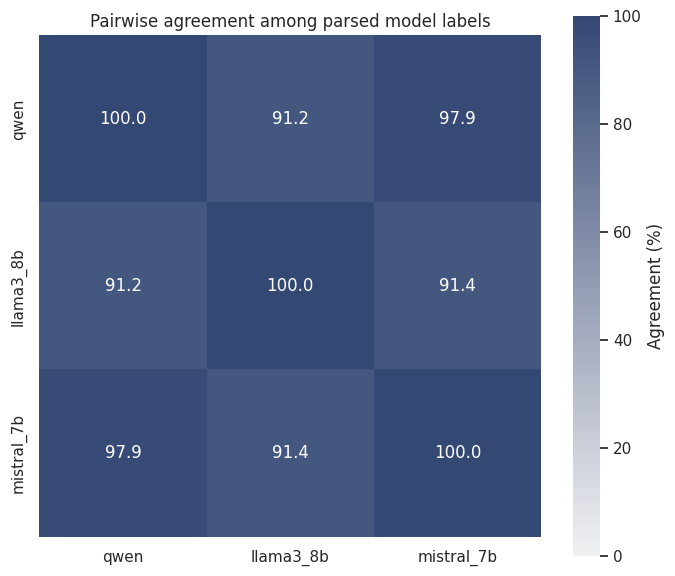

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/pairwise_model_agreement_heatmap.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/pairwise_model_agreement_heatmap.png')

In [10]:
agreement_matrix = pd.DataFrame(np.eye(len(MODEL_NAMES)), index=MODEL_NAMES, columns=MODEL_NAMES)
pairwise_rows = []

for index, model_a in enumerate(MODEL_NAMES):
    for model_b in MODEL_NAMES[index + 1:]:
        mask = combined[f"{model_a}_parse_ok"] & combined[f"{model_b}_parse_ok"]
        agreement = (
            combined.loc[mask, f"{model_a}_label"].astype(int).to_numpy()
            == combined.loc[mask, f"{model_b}_label"].astype(int).to_numpy()
        ).mean()
        agreement_matrix.loc[model_a, model_b] = agreement
        agreement_matrix.loc[model_b, model_a] = agreement
        pairwise_rows.append({
            "model_a": model_a,
            "model_b": model_b,
            "n_both_parsed": int(mask.sum()),
            "agreement_percent": 100 * agreement,
        })

pairwise_agreement = pd.DataFrame(pairwise_rows)
save_table(pairwise_agreement, "pairwise_model_agreement.csv")
display(pairwise_agreement)

figure, axis = plt.subplots(figsize=(7, 6))
sns.heatmap(
    100 * agreement_matrix,
    annot=True,
    fmt=".1f",
    cmap=sns.light_palette(LCDS_PALETTE[0], as_cmap=True),
    vmin=0,
    vmax=100,
    square=True,
    cbar_kws={"label": "Agreement (%)"},
    ax=axis,
)
axis.set_title("Pairwise agreement among parsed model labels")
save_figure(figure, "pairwise_model_agreement_heatmap")

## 11. Yearly consensus table and TRUE-versus-rest counts

**Outputs:** `yearly_three_model_consensus_trend.csv` and `yearly_TRUE_vs_rest_logscale`

Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/yearly_three_model_consensus_trend.csv


,year_int,total_candidates,three_model_TRUE_agreement,three_model_FALSE_agreement,qwen_TRUE,llama3_8b_TRUE,mistral_7b_TRUE,rest_NOT_three_model_TRUE_agreement,three_model_TRUE_agreement_rate_percent,rest_rate_percent
0,2014,1748,27,1604,34,135,41,1721,1.544622,98.455378
1,2015,2244,59,2014,71,219,87,2185,2.629234,97.370766
2,2016,3210,139,2877,153,314,179,3071,4.330218,95.669782
3,2017,4143,279,3514,307,596,355,3864,6.734251,93.265749
4,2018,5698,541,4658,588,1006,631,5157,9.494559,90.505441
5,2019,8151,924,6451,989,1669,1034,7227,11.336032,88.663968
6,2020,11837,1486,9208,1606,2547,1668,10351,12.553857,87.446143
7,2021,16798,2083,13129,2206,3583,2341,14715,12.400286,87.599714
8,2022,19682,2616,15231,2756,4357,2888,17066,13.291332,86.708668
9,2023,23506,3512,17548,3702,5838,3844,19994,14.940866,85.059134


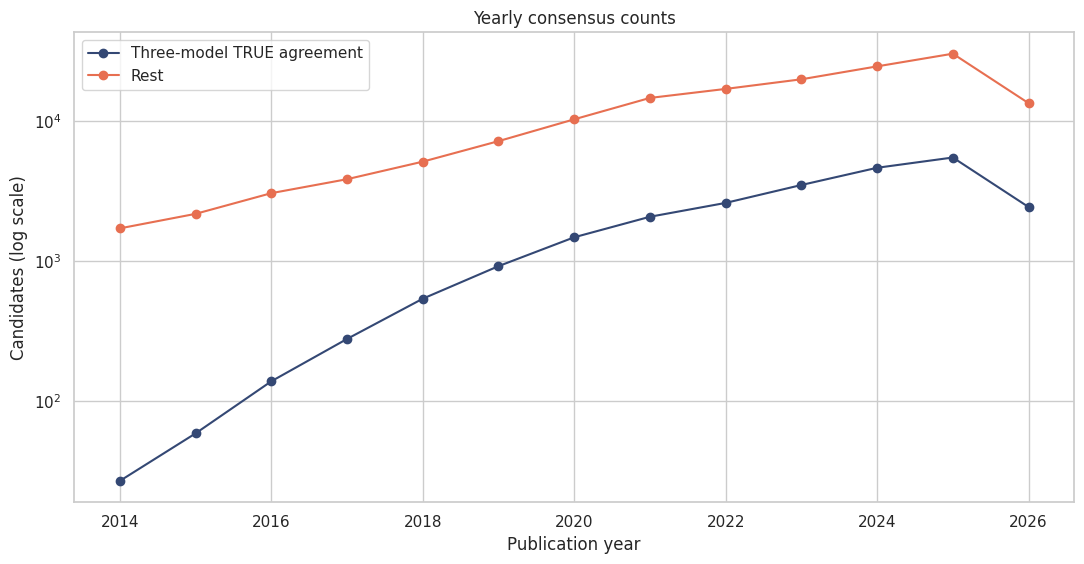

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/yearly_TRUE_vs_rest_logscale.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/yearly_TRUE_vs_rest_logscale.png')

In [11]:
year_data = combined.dropna(subset=["year_int"]).copy()
year_data["year_int"] = year_data["year_int"].astype(int)

yearly = year_data.groupby("year_int").agg(
    total_candidates=("id", "count"),
    three_model_TRUE_agreement=("three_model_TRUE_agreement", "sum"),
    three_model_FALSE_agreement=("three_model_FALSE_agreement", "sum"),
    qwen_TRUE=("qwen_true", "sum"),
    llama3_8b_TRUE=("llama3_8b_true", "sum"),
    mistral_7b_TRUE=("mistral_7b_true", "sum"),
).reset_index()
yearly["rest_NOT_three_model_TRUE_agreement"] = yearly["total_candidates"] - yearly["three_model_TRUE_agreement"]
yearly["three_model_TRUE_agreement_rate_percent"] = 100 * yearly["three_model_TRUE_agreement"] / yearly["total_candidates"]
yearly["rest_rate_percent"] = 100 - yearly["three_model_TRUE_agreement_rate_percent"]

save_table(yearly, "yearly_three_model_consensus_trend.csv")
display(yearly)

figure, axis = plt.subplots(figsize=(11, 5.8))
axis.plot(yearly["year_int"], yearly["three_model_TRUE_agreement"], marker="o", color=LCDS_PALETTE[0], label="Three-model TRUE agreement")
axis.plot(yearly["year_int"], yearly["rest_NOT_three_model_TRUE_agreement"], marker="o", color=LCDS_PALETTE[4], label="Rest")
axis.set_yscale("log")
axis.set(title="Yearly consensus counts", xlabel="Publication year", ylabel="Candidates (log scale)")
axis.legend()
save_figure(figure, "yearly_TRUE_vs_rest_logscale")

## 12. Yearly three-model TRUE-agreement rate

**Figure:** `yearly_three_model_TRUE_agreement_rate`

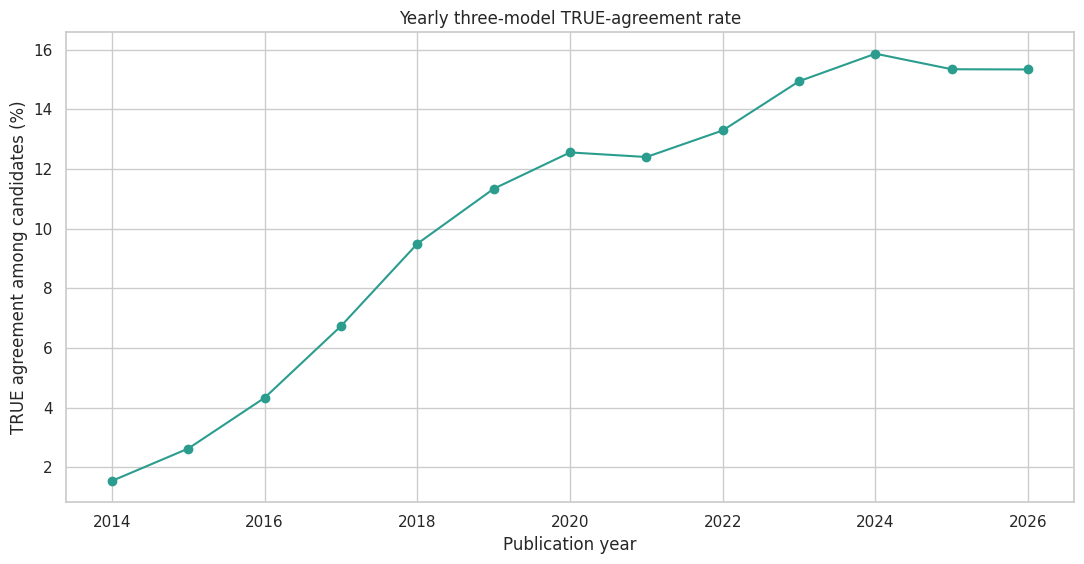

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/yearly_three_model_TRUE_agreement_rate.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/yearly_three_model_TRUE_agreement_rate.png')

In [12]:
figure, axis = plt.subplots(figsize=(11, 5.8))
axis.plot(yearly["year_int"], yearly["three_model_TRUE_agreement_rate_percent"], marker="o", color=LCDS_PALETTE[3])
axis.set(
    title="Yearly three-model TRUE-agreement rate",
    xlabel="Publication year",
    ylabel="TRUE agreement among candidates (%)",
)
save_figure(figure, "yearly_three_model_TRUE_agreement_rate")

## 13. Yearly positive predictions by model

**Figure:** `yearly_model_TRUE_counts`

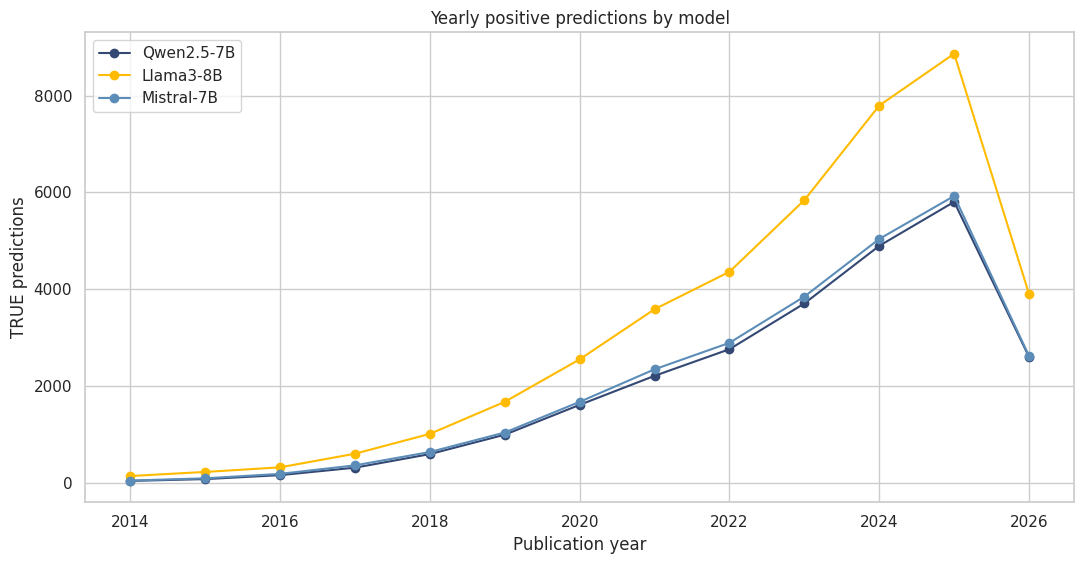

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/yearly_model_TRUE_counts.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/yearly_model_TRUE_counts.png')

In [13]:
figure, axis = plt.subplots(figsize=(11, 5.8))
for model, color in zip(MODEL_NAMES, LCDS_PALETTE[:3]):
    axis.plot(yearly["year_int"], yearly[f"{model}_TRUE"], marker="o", color=color, label=MODEL_DISPLAY[model])
axis.set(title="Yearly positive predictions by model", xlabel="Publication year", ylabel="TRUE predictions")
axis.legend()
save_figure(figure, "yearly_model_TRUE_counts")

## 14. Explicit UK Biobank mentions

**Outputs:** `explicit_ukb_mention_summary.csv` and `explicit_ukb_mention_by_binary_split`

/tmp/ipykernel_1453/675710981.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  combined["explicit_ukb_title_or_abstract"] = combined["analysis_text"].str.contains(ukb_pattern, na=False)


Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/explicit_ukb_mention_summary.csv


,binary_split,n,explicit_ukb,explicit_ukb_percent
0,Rest: not three-model TRUE agreement,154048,573,0.371962
1,Three-model TRUE agreement,24295,23121,95.167730


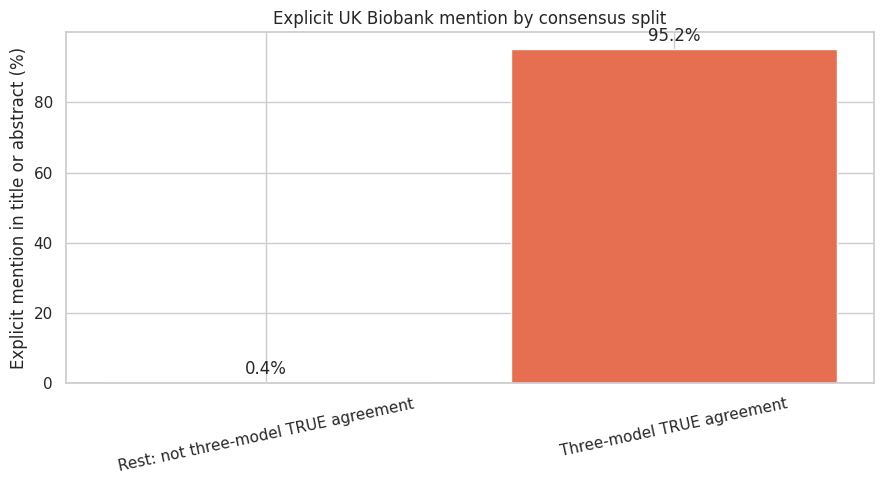

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/explicit_ukb_mention_by_binary_split.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/explicit_ukb_mention_by_binary_split.png')

In [14]:
ukb_pattern = re.compile(
    r"\b(uk\s*biobank|u\.?k\.?\s*biobank|united\s+kingdom\s+biobank|ukb|ukbb)\b",
    flags=re.I,
)
combined["analysis_text"] = analysis_text(combined)
combined["explicit_ukb_title_or_abstract"] = combined["analysis_text"].str.contains(ukb_pattern, na=False)
combined["binary_split"] = np.where(
    combined["three_model_TRUE_agreement"],
    "Three-model TRUE agreement",
    "Rest: not three-model TRUE agreement",
)

explicit_summary = combined.groupby("binary_split").agg(
    n=("id", "count"),
    explicit_ukb=("explicit_ukb_title_or_abstract", "sum"),
).reset_index()
explicit_summary["explicit_ukb_percent"] = 100 * explicit_summary["explicit_ukb"] / explicit_summary["n"]
save_table(explicit_summary, "explicit_ukb_mention_summary.csv")
display(explicit_summary)

figure, axis = plt.subplots(figsize=(9, 5))
bars = axis.bar(explicit_summary["binary_split"], explicit_summary["explicit_ukb_percent"], color=[LCDS_PALETTE[0], LCDS_PALETTE[4]])
axis.set(title="Explicit UK Biobank mention by consensus split", ylabel="Explicit mention in title or abstract (%)")
axis.tick_params(axis="x", rotation=12)
axis.bar_label(bars, fmt="%.1f%%", padding=3)
save_figure(figure, "explicit_ukb_mention_by_binary_split")

## 15. Keyword-category profile

**Outputs:** `keyword_category_summary.csv` and `keyword_category_profile_by_binary_split`

/tmp/ipykernel_1453/1742742162.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = text.str.contains(pattern, case=False, regex=True, na=False)
/tmp/ipykernel_1453/1742742162.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hits = text.str.contains(pattern, case=False, regex=True, na=False)


Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/keyword_category_summary.csv


,binary_split,category,n_group,n_with_category,percent_with_category
0,Rest: not three-model TRUE agreement,explicit UKB,154048,573,0.371962
1,Rest: not three-model TRUE agreement,generic biobank,154048,6067,3.938383
2,Rest: not three-model TRUE agreement,UK population cue,154048,5975,3.878661
3,Rest: not three-model TRUE agreement,cohort / participants,154048,46749,30.347035
4,Rest: not three-model TRUE agreement,genetics / genomics,154048,45062,29.251921
5,Rest: not three-model TRUE agreement,imaging,154048,12279,7.970892
6,Rest: not three-model TRUE agreement,linked records / EHR,154048,4706,3.054892
7,Rest: not three-model TRUE agreement,machine learning,154048,11174,7.253583
8,Rest: not three-model TRUE agreement,cardiometabolic,154048,42202,27.395357
9,Rest: not three-model TRUE agreement,cancer,154048,23638,15.344568


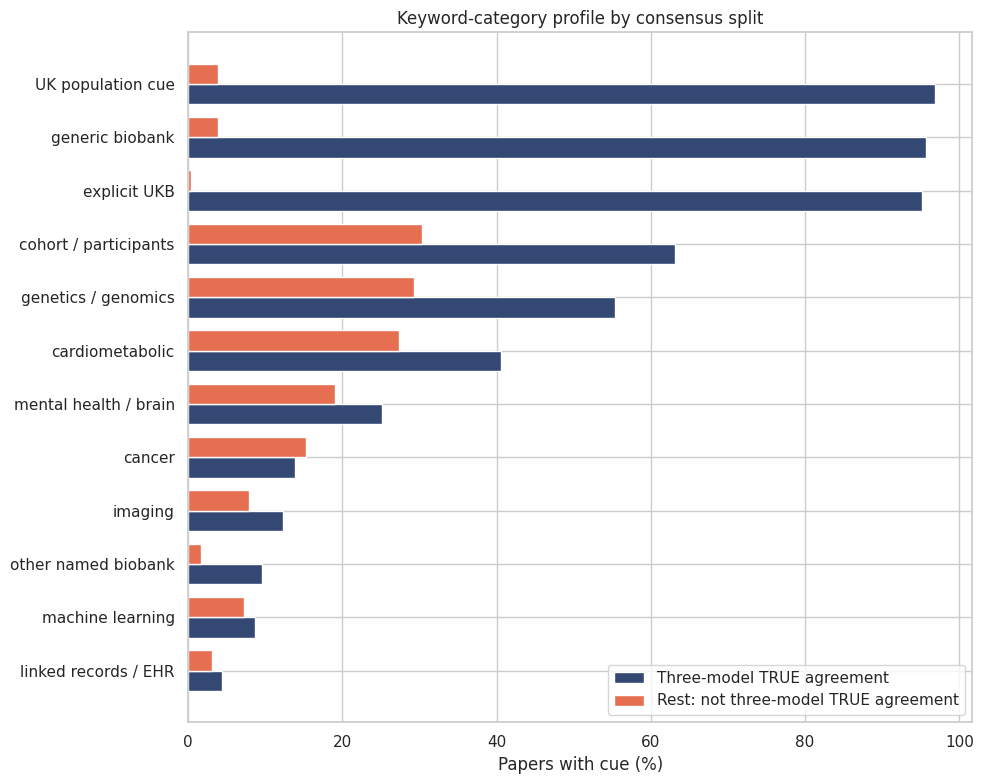

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/keyword_category_profile_by_binary_split.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/keyword_category_profile_by_binary_split.png')

In [15]:
CATEGORY_PATTERNS = {
    "explicit UKB": r"\b(uk\s*biobank|u\.?k\.?\s*biobank|united\s+kingdom\s+biobank|ukb|ukbb)\b",
    "generic biobank": r"\b(biobank|biobanking|biobanks)\b",
    "UK population cue": r"\b(uk|british|england|scotland|wales|united kingdom)\b",
    "cohort / participants": r"\b(cohort|participants|population[- ]based|prospective|baseline assessment)\b",
    "genetics / genomics": r"\b(genetic|genomic|genotype|genotyping|gwas|polygenic|exome|sequencing)\b",
    "imaging": r"\b(imaging|mri|brain imaging|cardiac imaging|radiomics)\b",
    "linked records / EHR": r"\b(linked records|hospital episode statistics|hes|electronic health records|ehr|registry|registries)\b",
    "machine learning": r"\b(machine learning|deep learning|artificial intelligence|neural network|prediction model)\b",
    "cardiometabolic": r"\b(cardiovascular|heart|diabetes|obesity|metabolic|hypertension)\b",
    "cancer": r"\b(cancer|tumou?r|oncology|carcinoma|neoplasm)\b",
    "mental health / brain": r"\b(depression|anxiety|psychiatric|mental health|brain|cognition|dementia)\b",
    "other named biobank": r"\b(china kadoorie|biobank japan|finn?gen|all of us|million veteran|lifelines|decode|cartagene)\b",
}

category_rows = []
for group_name, group in combined.groupby("binary_split"):
    text = analysis_text(group)
    for category, pattern in CATEGORY_PATTERNS.items():
        hits = text.str.contains(pattern, case=False, regex=True, na=False)
        category_rows.append({
            "binary_split": group_name,
            "category": category,
            "n_group": len(group),
            "n_with_category": int(hits.sum()),
            "percent_with_category": 100 * hits.mean(),
        })

category_summary = pd.DataFrame(category_rows)
save_table(category_summary, "keyword_category_summary.csv")
display(category_summary)

pivot = category_summary.pivot(index="category", columns="binary_split", values="percent_with_category").fillna(0)
true_column = "Three-model TRUE agreement"
rest_column = "Rest: not three-model TRUE agreement"
pivot = pivot.sort_values(true_column)
y = np.arange(len(pivot))

figure, axis = plt.subplots(figsize=(10, 8))
axis.barh(y - 0.19, pivot[true_column], height=0.38, color=LCDS_PALETTE[0], label=true_column)
axis.barh(y + 0.19, pivot[rest_column], height=0.38, color=LCDS_PALETTE[4], label=rest_column)
axis.set_yticks(y, pivot.index)
axis.set(title="Keyword-category profile by consensus split", xlabel="Papers with cue (%)")
axis.legend()
save_figure(figure, "keyword_category_profile_by_binary_split")

## 16. TF-IDF discriminative terms

**Outputs:**

- `tfidf_discriminative_terms.csv`
- `tfidf_terms_associated_with_three_model_TRUE_agreement`
- `tfidf_terms_associated_with_rest`

Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/tfidf_discriminative_terms.csv


,term,mean_tfidf_three_model_TRUE_agreement,mean_tfidf_rest,difference_TRUE_minus_rest
11391,uk,0.024395,0.000783,0.023611
1982,biobank,0.024214,0.000916,0.023298
11393,uk biobank,0.023259,0.000065,0.023195
9780,risk,0.041585,0.018659,0.022926
5089,genetic,0.027560,0.012991,0.014570
812,95,0.024527,0.011567,0.012960
2581,ci,0.023513,0.011000,0.012513
814,95 ci,0.021524,0.009954,0.011571
1712,associations,0.016890,0.006003,0.010887
1670,association,0.020442,0.009604,0.010839


,term,mean_tfidf_three_model_TRUE_agreement,mean_tfidf_rest,difference_TRUE_minus_rest
8330,patients,0.007228,0.022303,-0.015075
9751,review,0.000644,0.010557,-0.009913
2447,cells,0.001892,0.010597,-0.008705
9590,research,0.005246,0.013678,-0.008433
2429,cell,0.004328,0.012271,-0.007944
3307,covid,0.006291,0.012917,-0.006626
11317,treatment,0.003190,0.009798,-0.006609
2748,clinical,0.008311,0.013971,-0.005661
3308,covid 19,0.005995,0.011420,-0.005425
5761,human,0.005229,0.010481,-0.005251


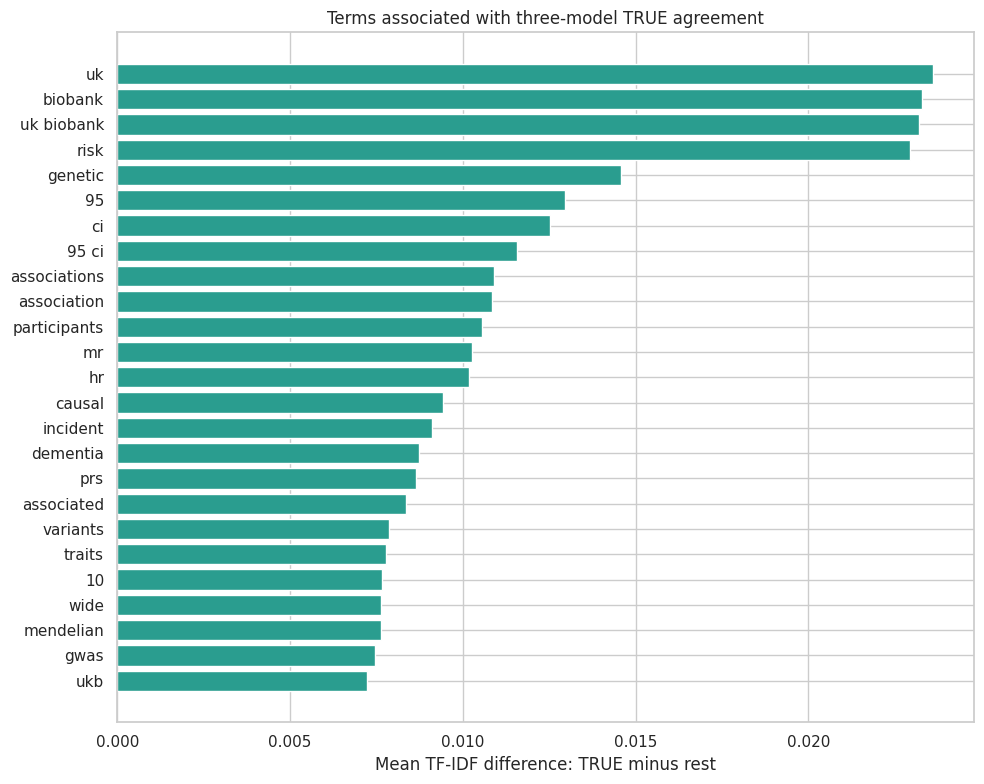

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/tfidf_terms_associated_with_three_model_TRUE_agreement.png


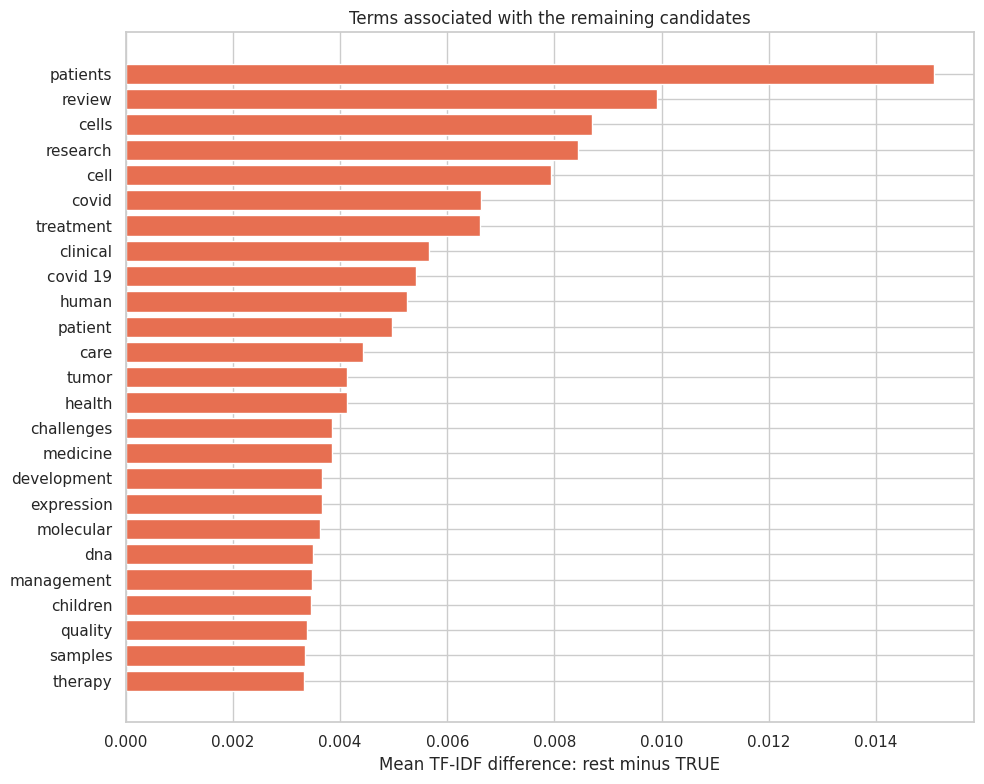

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/tfidf_terms_associated_with_rest.png


PosixPath('/content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/tfidf_terms_associated_with_rest.png')

In [16]:
tfidf_true = three_true.sample(n=min(len(three_true), MAX_TFIDF_PER_GROUP), random_state=SEED)
tfidf_rest = rest.sample(n=min(len(rest), MAX_TFIDF_PER_GROUP), random_state=SEED)
tfidf_data = pd.concat([
    tfidf_true.assign(binary_split="Three-model TRUE agreement"),
    tfidf_rest.assign(binary_split="Rest: not three-model TRUE agreement"),
], ignore_index=True)
tfidf_data["analysis_text"] = analysis_text(tfidf_data)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5 if len(tfidf_data) >= 1_000 else 2,
    max_df=0.85,
    max_features=12_000,
)
matrix = vectorizer.fit_transform(tfidf_data["analysis_text"])
terms = np.asarray(vectorizer.get_feature_names_out())
true_mask = tfidf_data["binary_split"].eq("Three-model TRUE agreement").to_numpy()
true_mean = np.asarray(matrix[true_mask].mean(axis=0)).ravel()
rest_mean = np.asarray(matrix[~true_mask].mean(axis=0)).ravel()

tfidf_terms = pd.DataFrame({
    "term": terms,
    "mean_tfidf_three_model_TRUE_agreement": true_mean,
    "mean_tfidf_rest": rest_mean,
    "difference_TRUE_minus_rest": true_mean - rest_mean,
}).sort_values("difference_TRUE_minus_rest", ascending=False)
save_table(tfidf_terms, "tfidf_discriminative_terms.csv")

top_true = tfidf_terms.head(25).iloc[::-1]
top_rest = tfidf_terms.tail(25).sort_values("difference_TRUE_minus_rest", ascending=True).iloc[::-1]
display(tfidf_terms.head(30))
display(tfidf_terms.tail(30).sort_values("difference_TRUE_minus_rest"))

figure, axis = plt.subplots(figsize=(10, 8))
axis.barh(top_true["term"], top_true["difference_TRUE_minus_rest"], color=LCDS_PALETTE[3])
axis.set(title="Terms associated with three-model TRUE agreement", xlabel="Mean TF-IDF difference: TRUE minus rest")
save_figure(figure, "tfidf_terms_associated_with_three_model_TRUE_agreement")

figure, axis = plt.subplots(figsize=(10, 8))
axis.barh(top_rest["term"], -top_rest["difference_TRUE_minus_rest"], color=LCDS_PALETTE[4])
axis.set(title="Terms associated with the remaining candidates", xlabel="Mean TF-IDF difference: rest minus TRUE")
save_figure(figure, "tfidf_terms_associated_with_rest")

## 17. Semantic separation diagnostic

This analysis uses the public `all-MiniLM-L6-v2` sentence-embedding model. It does not call any tagging model. Set `RUN_SEMANTIC_ANALYSIS=False` in Section 2 to skip it.

**Outputs:**

- `semantic_sample_with_coordinates.csv`
- `semantic_metrics.csv`
- `semantic_map_TRUE_agreement_vs_rest`
- `semantic_map_by_year`

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/semantic_sample_with_coordinates.csv
Saved table: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/semantic_metrics.csv


,metric,value
0,embedding_method,sentence-transformers/all-MiniLM-L6-v2
1,semantic_sample_size,6000
2,semantic_sample_three_model_TRUE_agreement,3000
3,semantic_sample_rest,3000
4,SI_silhouette_index_cosine,0.034907
5,centroid_cosine_similarity,0.940377
6,centroid_cosine_distance,0.059623


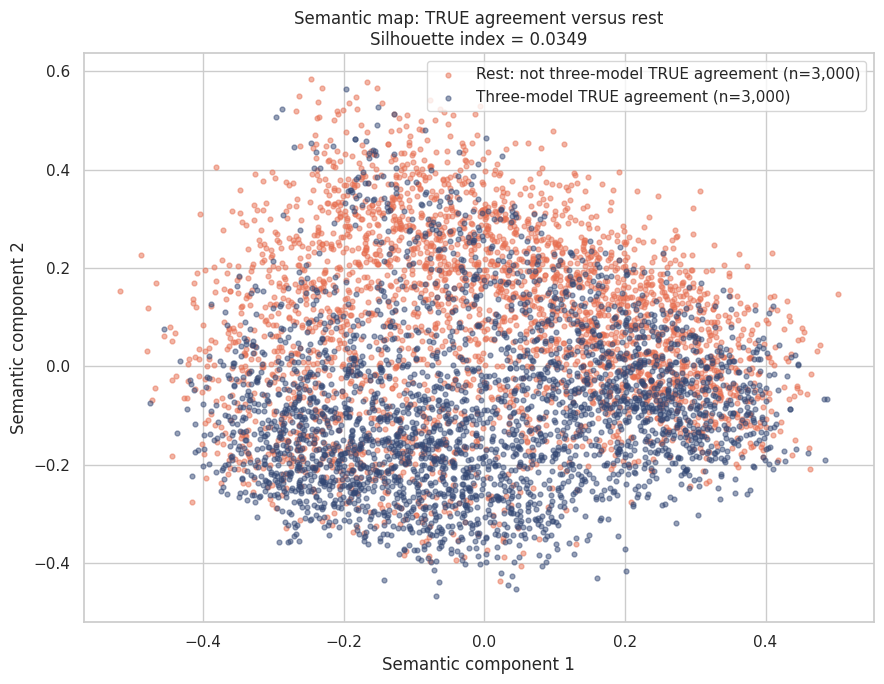

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/semantic_map_TRUE_agreement_vs_rest.png


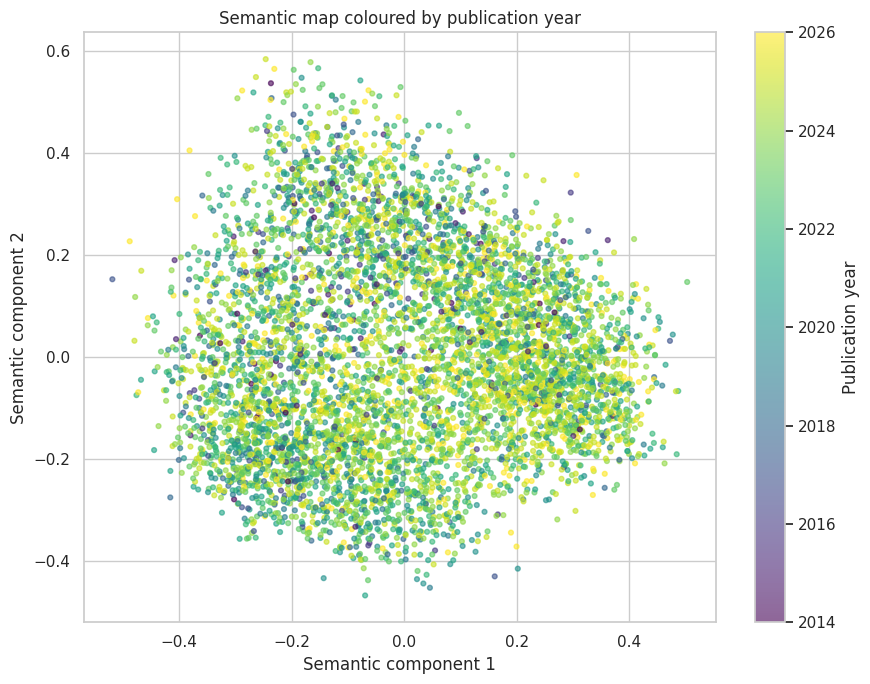

Saved figure: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun/figures/semantic_map_by_year.png


In [17]:
if RUN_SEMANTIC_ANALYSIS:
    from sentence_transformers import SentenceTransformer

    semantic_true = three_true.sample(n=min(len(three_true), MAX_SEMANTIC_PER_GROUP), random_state=SEED)
    semantic_rest = rest.sample(n=min(len(rest), MAX_SEMANTIC_PER_GROUP), random_state=SEED)
    semantic_data = pd.concat([
        semantic_true.assign(binary_split="Three-model TRUE agreement"),
        semantic_rest.assign(binary_split="Rest: not three-model TRUE agreement"),
    ], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
    semantic_data["analysis_text"] = analysis_text(semantic_data).str.slice(0, 3_500)
    labels = semantic_data["binary_split"].eq("Three-model TRUE agreement").astype(int).to_numpy()

    embedding_method = "sentence-transformers/all-MiniLM-L6-v2"
    try:
        embedder = SentenceTransformer(embedding_method)
        embeddings = embedder.encode(
            semantic_data["analysis_text"].tolist(),
            batch_size=128,
            show_progress_bar=True,
            normalize_embeddings=True,
        )
        del embedder
        gc.collect()
    except Exception as error:
        print(f"Sentence embeddings unavailable ({error}); using TF-IDF/SVD fallback.")
        fallback = TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.9,
            max_features=12_000,
        )
        text_matrix = fallback.fit_transform(semantic_data["analysis_text"])
        components = min(100, text_matrix.shape[0] - 1, text_matrix.shape[1] - 1)
        embeddings = TruncatedSVD(n_components=components, random_state=SEED).fit_transform(text_matrix)
        embeddings /= np.maximum(np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-12)
        embedding_method = "TF-IDF + TruncatedSVD fallback"

    silhouette = silhouette_score(embeddings, labels, metric="cosine")
    true_centroid = embeddings[labels == 1].mean(axis=0)
    rest_centroid = embeddings[labels == 0].mean(axis=0)
    true_centroid /= max(np.linalg.norm(true_centroid), 1e-12)
    rest_centroid /= max(np.linalg.norm(rest_centroid), 1e-12)
    centroid_similarity = float(np.dot(true_centroid, rest_centroid))

    coordinates = PCA(n_components=2, random_state=SEED).fit_transform(embeddings)
    semantic_data[["semantic_x", "semantic_y"]] = coordinates
    semantic_metrics = pd.DataFrame([
        {"metric": "embedding_method", "value": embedding_method},
        {"metric": "semantic_sample_size", "value": len(semantic_data)},
        {"metric": "semantic_sample_three_model_TRUE_agreement", "value": int(labels.sum())},
        {"metric": "semantic_sample_rest", "value": int((labels == 0).sum())},
        {"metric": "SI_silhouette_index_cosine", "value": silhouette},
        {"metric": "centroid_cosine_similarity", "value": centroid_similarity},
        {"metric": "centroid_cosine_distance", "value": 1 - centroid_similarity},
    ])
    save_table(semantic_data, "semantic_sample_with_coordinates.csv")
    save_table(semantic_metrics, "semantic_metrics.csv")
    display(semantic_metrics)

    figure, axis = plt.subplots(figsize=(9, 7))
    for group, color in zip(
        ["Rest: not three-model TRUE agreement", "Three-model TRUE agreement"],
        [LCDS_PALETTE[4], LCDS_PALETTE[0]],
    ):
        subset = semantic_data[semantic_data["binary_split"].eq(group)]
        axis.scatter(subset["semantic_x"], subset["semantic_y"], s=12, alpha=0.5, color=color, label=f"{group} (n={len(subset):,})")
    axis.set(
        title=f"Semantic map: TRUE agreement versus rest\nSilhouette index = {silhouette:.4f}",
        xlabel="Semantic component 1",
        ylabel="Semantic component 2",
    )
    axis.legend()
    save_figure(figure, "semantic_map_TRUE_agreement_vs_rest")

    year_mask = semantic_data["year_int"].notna()
    figure, axis = plt.subplots(figsize=(9, 7))
    points = axis.scatter(
        semantic_data.loc[year_mask, "semantic_x"],
        semantic_data.loc[year_mask, "semantic_y"],
        c=semantic_data.loc[year_mask, "year_int"].astype(int),
        cmap="viridis",
        s=12,
        alpha=0.6,
    )
    axis.set(title="Semantic map coloured by publication year", xlabel="Semantic component 1", ylabel="Semantic component 2")
    figure.colorbar(points, ax=axis, label="Publication year")
    save_figure(figure, "semantic_map_by_year")
else:
    print("Semantic analysis skipped by configuration.")

## 18. Output inventory

This final cell confirms which tables and figures were created.

In [18]:
table_files = sorted(OUTPUT_DIR.glob("*.csv"))
figure_files = sorted(FIGURE_DIR.glob("*.png"))

inventory = pd.DataFrame(
    [{"type": "table", "file": path.name, "size_kb": path.stat().st_size / 1024} for path in table_files]
    + [{"type": "figure", "file": path.name, "size_kb": path.stat().st_size / 1024} for path in figure_files]
)
display(inventory)
print(f"Created {len(table_files)} CSV tables and {len(figure_files)} PNG figures.")
print(f"Output folder: {OUTPUT_DIR}")

,type,file,size_kb
0,table,combined_consensus_normalised.csv,358895.415039
1,table,consensus_group_distribution.csv,0.171875
2,table,dataset_overview.csv,0.289062
3,table,explicit_ukb_mention_summary.csv,0.168945
4,table,keyword_category_summary.csv,1.915039
5,table,model_positive_rate_summary.csv,0.291992
6,table,pairwise_model_agreement.csv,0.170898
7,table,rest_NOT_three_model_TRUE_agreement.csv,304850.814453
8,table,semantic_metrics.csv,0.290039
9,table,semantic_sample_with_coordinates.csv,23930.185547


Created 15 CSV tables and 13 PNG figures.
Output folder: /content/drive/MyDrive/backup/Downloads/0_UKB/qwen_p2_full_tagging_final/three_model_consensus_analysis/analysis_only_rerun
